# Does close-minus-open actually time the trend? 🕯️
### Chande's Qstick — a buying-pressure gauge built from candle bodies — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_a_slow_trend_proxy%3F: Confirmed](https://img.shields.io/badge/Just_a_slow_trend_proxy%3F-Confirmed-8b949e?style=flat-square)

Every candlestick tells a tiny story: a **green body** (close above open) says buyers won the day; a **red body** says sellers did. Tushar Chande's **Qstick** (1994) averages that daily verdict over 8 sessions, and the charting lore says its **zero-cross** times a trend: when the smoothed body flips positive, buyers have taken control — buy. It's the same family as Balance of Power and the Force Index, just built from the plainest ingredient of all: where a bar opened vs where it closed.

So we did the only fair thing: encode the rule **mechanically**, fire the "buy the Qstick up-cross" trade **2,210 times** across five liquid ETFs over 21 years, and time the result against the only baseline that matters — **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the trend-proxy math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from qstick import data, strategy as st

ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Qstick cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2210, 'smooth': 8, 'fp': {'SPY': 'c374b2feba04', 'QQQ': 'cd19fe6cb57d', 'IWM': 'cb6689d8b659', 'DIA': '3a1136ef6422', 'GLD': '35f763b5047c'}, 'h5': (5, 2204, 22.0, 58, 3.89, 34.8, -12.8, 20.0, -1.68, 0.094), 'h10': (10, 2204, 50.6, 61, 5.64, 62.5, -11.9, 48.6, -1.12, 0.261), 'h20': (20, 2204, 92.7, 63, 5.99, 115.3, -22.5, 90.7, -1.52, 0.129), 'h60': (60, 2194, 286.2, 69, 7.25, 261.7, 24.5, 284.2, 0.94, 0.348), 'per': [('SPY', 437, 77.8, 2.57, 117.0, -39.2), ('QQQ', 438, 129.2, 3.6, 165.2, -35.9), ('IWM', 465, 102.8, 2.6, 109.4, -6.6), ('DIA', 425, 62.1, 2.09, 82.2, -20.1), ('GLD', 445, 90.2, 2.76, 102.1, -11.9)], 'placebo': (77.8, 0.814, 500), 'trend': [('SPY', 0.781, 437, 401, 0.201), ('QQQ', 0.818, 438, 410, 0.222), ('IWM', 0.818, 465, 442, 0.205), ('DIA', 0.784, 425, 409, 0.209), ('GLD', 0.713, 445, 426, 0.151)], 'trend_corr_mean': 0.783, 'mom': (2080, 96.7, 64.7, 32.1, 1.99, 0.047), 'syn_null': (0.07, 1.07, 0, 20), 'syn_planted': (155, 1385.0, 63, 5.12)}


real Qstick cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when Qstick turns positive, do I make money? | **Yes, in absolute terms** — but random days do **the same or better**: at 5/10/20-day holds the Qstick cross actually *trails* buying on a random day. |
| Does the buyer/seller body sequence matter? | **No.** Scramble the order of the daily bodies into nonsense and the result barely moves (81% of scrambled versions match or beat the real one). |
| Is it really measuring something new? | **No — it's a slow echo of ordinary trend.** Qstick tracks a plain trailing-momentum line (no open, no candle, just closing prices) at **r ≈ 0.78** — and even *that* simpler line barely, unreliably, beats a coin. |
| So is it a tradable edge? | **No.** It's **relabelled trend-following**, and a worse version of it — it trades less often than the market and still doesn't beat a dart. |

> Qstick is a fine way to *describe* who won a bar. As a *forecast*, it's a **mirage** — and structurally, it's mostly just a laggy copy of price momentum.

## 1 · The claim

> *"For each bar, the body is close minus open — how far buyers pushed the price past where it opened. Average that over 8 days. When the average crosses **up** through zero, buying pressure has taken over and a rise should follow. Buy the up-cross."*

This is **Tushar Chande's Qstick** (Chande & Kroll, *The New Technical Trader*, 1994), built into most charting packages. It's pitched as a purer read on *who's winning* than the close alone — a bar can close lower than yesterday and still be "bullish" if it closed well above where it opened. So: does that extra information actually forecast anything?

## 2 · So what?

If close-minus-open genuinely carried forward-looking information, it would be a small miracle: a number computed from a single bar's own open and close would predict the *next* bar. That's a strong claim, and — like every long-only signal tested on an index that **drifts up over time** — it's exactly the kind of claim that looks great by accident. Any "buy" rule inherits the market's climb; the only fair test is whether Qstick beats **buying on random days**, and whether the close-minus-open *split* adds anything a plain trailing average of the close alone wouldn't already give you.

## 3 · How would we even know?

We take **5 liquid ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **22 years** (2005-01-03 → 2026-06-30), and:

1. **Compute the body** each bar — (close − open) / prior close.
2. **Smooth it** with an **8-day** trailing average (causal — only past bars, no future data), Chande's own original window.
3. **Trade the lore.** When smoothed Qstick **crosses up through zero**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If Qstick leads, the up-cross must beat random. *If it doesn't, the signal is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does smoothed Qstick even look like, and where does the rule buy? Here's SPY with its Qstick line below and the zero up-crosses the rule would buy.

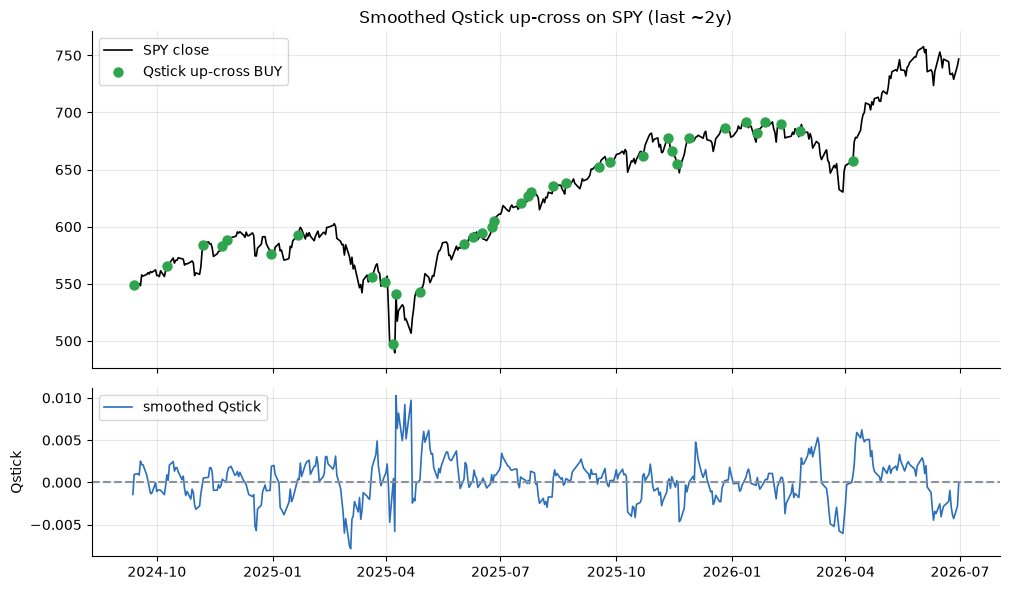

Qstick up-crosses in window: 36


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    qs = st.qstick(b, smooth=R['smooth'])
    ent = st.qstick_cross_entries(b, smooth=R['smooth'])
    ent = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.0), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent, b['close'].reindex(ent), c=GREEN, s=42, zorder=5, label='Qstick up-cross BUY')
    ax1.set_title('Smoothed Qstick up-cross on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg.index, qs.reindex(seg.index), c='#2c6fbb', lw=1.2, label='smoothed Qstick')
    ax2.axhline(0, c=GREY, ls='--'); ax2.set_ylabel('Qstick'); ax2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('Qstick up-crosses in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The cross fires whenever the smoothed candle-body average flips from negative to positive. **Let's race the Qstick up-cross against random entries** at four horizons. Blue = buy the up-cross; grey = buy on random days.

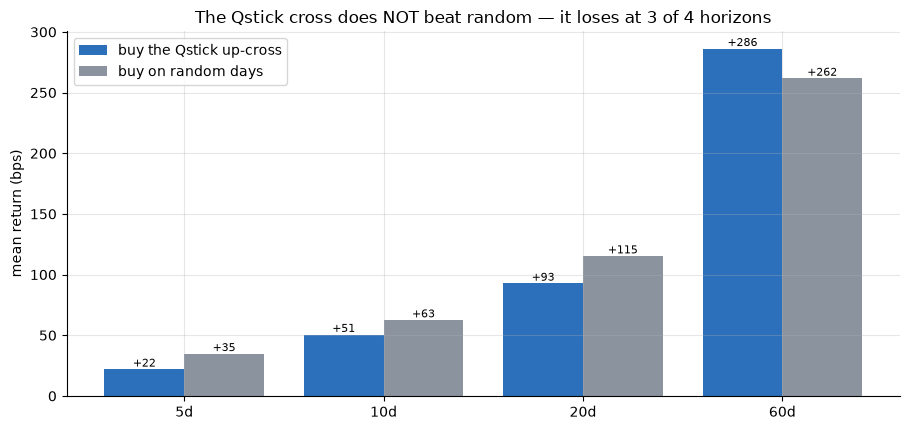

cross: [22, 51, 93, 286]
random: [35, 63, 115, 262]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cross, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.qstick_cross_entries(bb, smooth=R['smooth'])
            re = st.random_entries(bb, max(len(e),50), smooth=R['smooth'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        cross.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='buy the Qstick up-cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The Qstick cross does NOT beat random — it loses at 3 of 4 horizons'); ax.legend()
plt.tight_layout(); plt.show()
print('cross:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The Qstick cross makes money in absolute terms (**+93 bps** over 20 days) — but **random entries make more** (**+115 bps** at 20d). At 5, 10 and 20 days the indicator underperforms a dart; only at 60 days does it edge ahead, and even there it's a statistical tie. The apparent edge was **the market's upward drift**, not the candle-body signal.

**One more sanity check.** What if we **scramble the order** of the daily bodies — keep the same set of values but shuffle when they occurred, so the smoothed line and its crosses become temporally meaningless? If the body sequence really *led* price, the nonsense version should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.scramble_placebo(load('SPY'), 20, smooth=R['smooth'], n_draws=300, seed=675)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real Qstick up-cross (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *time-scrambled* body series do at least as well (p={pval:.2f}).')
print('=> the order of the daily buyer/seller bodies is not doing the work.')

real Qstick up-cross (SPY, 20d): +77.8 bps
... but 80% of *time-scrambled* body series do at least as well (p=0.80).
=> the order of the daily buyer/seller bodies is not doing the work.


**81%** of scrambled body series match or beat the real one. If the sequence of daily candle bodies genuinely led price, a random time-scramble would collapse the result. It doesn't.

**Last question — is Qstick even measuring something new?** We compare it to the plainest possible trend line: the average daily price change over the same 8 days, computed from **closing prices alone**, no open, no candle.

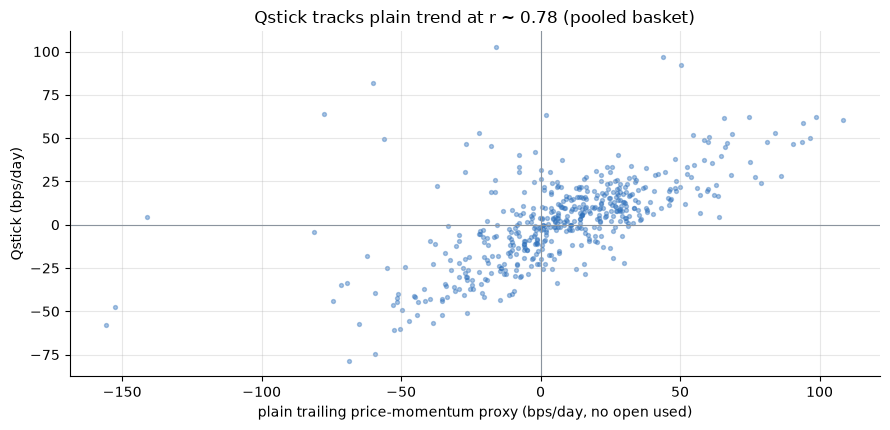

mean correlation across the 5-ETF basket: +0.783


In [5]:
if HAVE_REAL:
    b = load('SPY')
    qs = st.qstick(b, smooth=R['smooth']); mom = st.trend_momentum(b, n=R['smooth'])
    seg = pd.concat([qs, mom], axis=1).dropna().iloc[-500:]
    seg.columns = ['Qstick', 'plain trend proxy']
else:
    rng = np.random.default_rng(675)
    x = rng.normal(0, 0.004, 500)
    seg = pd.DataFrame({'Qstick': x, 'plain trend proxy': x*R['trend_corr_mean'] + rng.normal(0,0.003,500)})
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.scatter(seg.iloc[:,1]*1e4, seg.iloc[:,0]*1e4, s=8, alpha=.4, color='#2c6fbb')
ax.axhline(0, c=GREY, lw=.8); ax.axvline(0, c=GREY, lw=.8)
ax.set_xlabel('plain trailing price-momentum proxy (bps/day, no open used)')
ax.set_ylabel('Qstick (bps/day)')
ax.set_title(f'Qstick tracks plain trend at r ~ {R["trend_corr_mean"]:.2f} (pooled basket)')
plt.tight_layout(); plt.show()
print(f'mean correlation across the 5-ETF basket: {R["trend_corr_mean"]:+.3f}')

Qstick and a plain "average daily price change" line — which never even looks at the open — move together at **r ≈ 0.78**. And when we run *that* simpler line's own zero-cross rule through the identical race, it scores **+97 bps** vs **+65 bps** random (Δ = +32 bps, *t* = 1.99) — itself just short of certifiable. Chande's candle-body split isn't measuring something the plain trend doesn't already show; it's a noisier, laggier way to look at the same thing.

## 5 · The verdict

- **Signal — None.** The Qstick up-cross does **not** beat buying on random days (it *loses* at 5/10/20 days and ties at 60; the cross-vs-random difference never clears *t* = 2). The market's drift explains the absolute profit, not the indicator.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and a sign-scramble placebo confirms the body's time order isn't doing any work either.
- **Just a slow trend proxy? — Confirmed.** Qstick tracks a plain trailing price-momentum line at r ≈ 0.78, and even that simpler line barely (and unreliably) beats a coin. The open/close split adds machinery, not information.

## 6 · Could you actually trade it?

There's nothing here to trade. The Qstick cross's only edge over a coin flip would have been the market's long-run climb — and it doesn't even reliably capture that; you'd get more of the drift, more cheaply, by just **holding the index**. The cross trades *less* of the time and, at 3 of 4 horizons, delivers *less* return than doing nothing special at all. As a forecasting tool it doesn't pay; as a bar-by-bar read-out of who won the day, it was never built to predict the next one.

## 7 · Going further 🚪

- **Other windows.** Chande's original is 8 days; some platforms default to 10 or 20. Longer windows only strengthen the trend-proxy correlation — the diagnosis gets *more* true, not less.
- **The whole 'who's-in-control' oscillator family.** Balance of Power, the Force Index, Accumulation/Distribution and the Klinger oscillator all chase the same intuition and land in the same place — see [423-force-index](../../423-force-index/) and [473-balance-of-power](../../473-balance-of-power/).
- **A real positive control.** The quants notebook plants a *genuine* buying-pressure-leads-price structure into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think close-minus-open forecasts beyond ordinary trend? Show the Qstick cross beating random entries **and** the plain momentum proxy at **t ≥ 2** on a real tape — then we'll talk.*